# A minimal PyCBC CPU chi-square precision example

**A phase rotation should preserve magnitude. PyCBC 2.11.0's CPU point routine loses this property after many float32 rotations.** This notebook calls the installed PyCBC code with one nonzero frequency sample. The correct bin power is exactly **1**; the saved complex64 result is **1.0109626** (about **1.10%** high). Explicit complex128 input stays close to 1.

This is a synthetic diagnostic, not a waveform or an estimate of error in a real search. It needs no data files. The core reproduction is the first two code cells; the plot and final chi-square call explain the result.

**Run:** select a Python kernel with PyCBC, NumPy and Matplotlib installed, then **Restart Kernel and Run All**. To reproduce the tested release in a fresh environment: `python -m pip install "pycbc==2.11.0" matplotlib jupyterlab`. Exact low-order digits can depend on the compiler and machine; a later PyCBC release may change the behavior.

**Version check:** PyCBC 2.11.0 was the latest stable release on [PyPI](https://pypi.org/project/PyCBC/2.11.0/) when checked on 21 September 2026. This notebook was rerun from a fresh kernel with that release.

In [1]:
import platform
import warnings

# Silence only LAL's unrelated notebook-output performance notice.
warnings.filterwarnings("ignore", message="Wswiglal-redir-stdio")
import numpy as np
import pycbc
from pycbc.types import Array
from pycbc.scheme import CPUScheme
from pycbc.vetoes.chisq_cpu import shift_sum

print(f"PyCBC {pycbc.__version__}; NumPy {np.__version__}; "
      f"Python {platform.python_version()}; {platform.system()} {platform.machine()}")

PyCBC 2.11.0; NumPy 2.3.5; Python 3.13.9; Darwin arm64


## 1. An answer we know exactly

`shift_sum` computes **S = |q₁|² + |q₂|²**, where each q is the Fourier sum within one frequency bin at a selected time sample. We put a single coefficient equal to 1 near the end of the first bin; all others are zero.

The first bin's sum is one unit-magnitude phase, and the second bin's sum is zero. Therefore **S = 1**, for every selected time sample. Both 0 and 1 are represented exactly in complex64, so input quantization cannot explain a discrepancy. No FFT or approximate reference is needed.

In [2]:
N = 2**20
sample = 100_000
bins = [0, N // 4, N // 2]       # Two equal-width frequency bins.
k = bins[1] - 1                 # Last coefficient of the first bin.
corr = np.zeros(N, dtype=np.complex64)
corr[k] = 1

print(f"{'input':<12} {'output':<10} {'S (expected 1)':>20} {'error (%)':>14}")
powers = {}
with CPUScheme():
    for dtype in (np.complex64, np.complex128):
        result = shift_sum(Array(corr.astype(dtype)), [sample], bins)
        powers[np.dtype(dtype).name] = float(result[0])
        print(f"{np.dtype(dtype).name:<12} {str(result.dtype):<10} "
              f"{result[0]:20.13f} {100 * (float(result[0]) - 1):14.8g}")

    # Controls: no rotation, and double-precision rotation.
    np.testing.assert_array_equal(shift_sum(Array(corr), [0], bins), [1.0])
np.testing.assert_allclose(powers['complex128'], 1.0, rtol=0, atol=1e-8)

input        output           S (expected 1)      error (%)
complex64    float32         1.0109626054764      1.0962605
complex128   float64         1.0000000000025  2.4551472e-10


## 2. Watch the error grow across a bin

The CPU implementation advances a phase factor by repeated multiplication: **phase ← phase × rotation**. For complex64 input, the phase, rotation and intermediate arithmetic use float32. Tiny rounding errors accumulate, so the stored phase factor drifts away from the unit circle. The recurrence still advances across zero-valued coefficients.

Move the single nonzero coefficient progressively farther into the same bin. Every case still has the exact answer 1. The horizontal axis counts the rotations before that coefficient is used. Every plotted value below comes from **PyCBC's compiled CPU routine**, not a Python imitation.

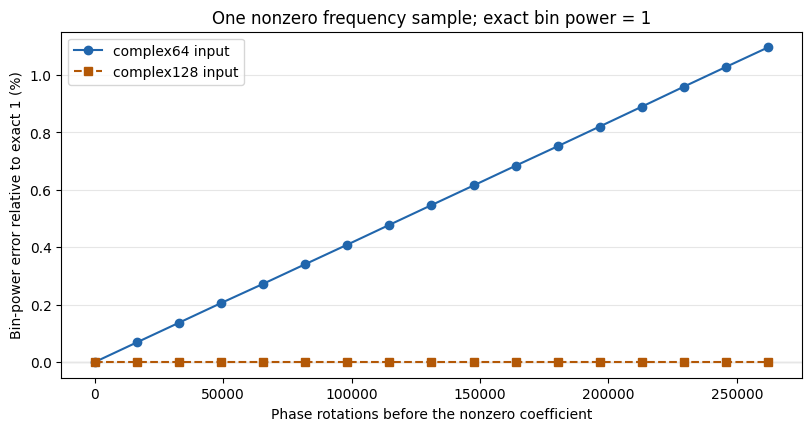

In [3]:
import matplotlib.pyplot as plt

positions = np.linspace(0, k, 17, dtype=int)
errors = {}
with CPUScheme():
    for dtype in (np.complex64, np.complex128):
        probe = Array(np.zeros(N, dtype=dtype))
        values = []
        for position in positions:
            probe[position] = 1
            values.append(float(shift_sum(probe, [sample], bins)[0]))
            probe[position] = 0
        errors[np.dtype(dtype).name] = 100 * (np.array(values) - 1)

fig, ax = plt.subplots(figsize=(8, 4.2), layout='constrained')
ax.plot(positions, errors['complex64'], 'o-', color='#2166ac', label='complex64 input')
ax.plot(positions, errors['complex128'], 's--', color='#b35806', label='complex128 input')
ax.axhline(0, color='0.35', linewidth=0.8, zorder=0)
ax.set(xlabel='Phase rotations before the nonzero coefficient',
       ylabel='Bin-power error relative to exact 1 (%)',
       title='One nonzero frequency sample; exact bin power = 1')
ax.ticklabel_format(axis='x', style='plain', useOffset=False)
ax.grid(axis='y', color='0.9')
ax.legend()
plt.show()

The complex128 errors are too small to distinguish from zero on this percentage scale; the table above gives the numerical value. The first plotted point has no preceding rotations and returns 1 even in complex64. As the nonzero coefficient moves farther into the bin, complex64 departs from 1.

## 3. The error reaches the chi-square statistic

The public selected-point function computes **χ² = (p S − |snr|²) × snr_norm²**. Here p = 2, |snr|² = 1 and snr_norm = 1, so the exact chi-square is also **1**.

Use the known full Fourier amplitude for `snr`, held fixed in complex128 in both calls. This isolates the error in the bin calculation; it is not a simulation of the rest of a search. The integer modulo below keeps the reference phase small before evaluating the exponential.

In [4]:
from pycbc.vetoes.chisq import power_chisq_at_points_from_precomputed

snr = np.array([np.exp(2j * np.pi * ((k * sample) % N) / N)], dtype=np.complex128)
chi_square = {}
print(f"{'correlation':<14} {'chi-square (expected 1)':>25} {'error (%)':>14}")
with CPUScheme():
    for dtype in (np.complex64, np.complex128):
        result = power_chisq_at_points_from_precomputed(
            Array(corr.astype(dtype)), snr, 1.0, bins, np.array([sample]))
        value = float(result[0])
        chi_square[np.dtype(dtype).name] = value
        print(f"{np.dtype(dtype).name:<14} {value:25.13f} {100 * (value - 1):14.8g}")

np.testing.assert_allclose(chi_square['complex128'], 1.0, rtol=0, atol=1e-8)

correlation      chi-square (expected 1)      error (%)
complex64                1.0219252109528      2.1925211
complex128               1.0000000000049  4.9102944e-10


## What this demonstrates

- Complex64 input selects float32 arithmetic in the CPU bin-sum routine; there is no automatic promotion to complex128 in that routine.
- A long sequence of rounded rotations can change the phase factor's magnitude and therefore the chi-square result. This one-coefficient example avoids cancellation or accumulation of many nonzero terms.
- Explicitly casting the same input to complex128 substantially reduces the error in this example. That is a diagnostic control, not a proposed complete fix or a performance measurement.
- No FFT was called in this experiment, so it requires no FFT-backend choice. The exact reference is the unit-magnitude identity.

The saved synthetic chi-square error is about **2.19%**. This deliberately isolated example does **not** estimate typical search errors or effects on detection sensitivity or false-alarm rates. It tests loss of unit magnitude; it does not measure the separate error from the CPU routine's truncated pi constant.

**Source:** PyCBC 2.11.0 [CPU recurrence and precision dispatch](https://github.com/gwastro/pycbc/blob/v2.11.0/pycbc/vetoes/chisq_cpu.pyx), and [selected-point chi-square formula](https://github.com/gwastro/pycbc/blob/v2.11.0/pycbc/vetoes/chisq.py). The longer [numerical report](https://github.com/xangma/pycbc/blob/e8b63f56ea444dca7b5ead91ca3a34da7398e3b5/docs/jax_chisq_numerics.rst) examines captured search inputs.